In [1]:
# Cell 1 — Install (PyTorch 2.5.1 + PyG wheels) and mount Drive
print("Installing required packages (this may take a few minutes)...")

# remove incompatible packages (safe to run)
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric >/dev/null 2>&1 || true

# PyTorch + CUDA 12.1 (supported by PyG wheels we use)
!pip install -q torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121

# PyG wheels
WHEEL_URL="https://data.pyg.org/whl/torch-2.5.1+cu121.html"
!pip install -q torch-scatter -f $WHEEL_URL
!pip install -q torch-sparse  -f $WHEEL_URL
!pip install -q torch-cluster -f $WHEEL_URL
!pip install -q torch-spline-conv -f $WHEEL_URL
!pip install -q torch-geometric

# DINOv2 dependency
!pip install -q timm

# other helpful packages
!pip install -q scikit-image==0.25.2 matplotlib pandas scikit-learn tqdm pillow

# mount drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import torch, torch_geometric
print("Installed versions:")
print("  torch:", torch.__version__, " cuda:", torch.version.cuda)
print("  pyg:", torch_geometric.__version__)


Installing required packages (this may take a few minutes)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 791.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 120.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 80.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 103.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 57.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 120.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 594.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0

In [2]:
# Cell 2 — imports, paths, dinov2, seeds
import os, time, json, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

# skimage
from skimage.segmentation import slic
from skimage.color import rgb2lab
from skimage import graph
from skimage import io as skio

# PyG
from torch_geometric.data import Data as GeometricData
from torch_geometric.loader import DataLoader as GeometricDataLoader

# DINOv2 model via timm
import timm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# load DINO model (vit_small_patch16_224.dino)
dino = timm.create_model("vit_small_patch16_224.dino", pretrained=True)
dino.eval()
dino.to(device)
print("DINOv2 model loaded.")

# output folder (all results stored here)
OUT_DIR = "/content/drive/MyDrive/RareImage/GNN1_Results"
os.makedirs(OUT_DIR, exist_ok=True)
CACHE_ROOT = "/content/cache_graphs"   # local fast cache (per split inside)
os.makedirs(CACHE_ROOT, exist_ok=True)

# reproducibility
torch.manual_seed(42)
np.random.seed(42)


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

DINOv2 model loaded.


In [3]:
# Cell 3 — Graph builder (SLIC + RAG + DINOv2 replication)
class SuperpixelGraphBuilder:
    def __init__(self, n_segments=60, compactness=10.0, max_side=None):
        """
        n_segments: recommended 40-80 (60 default)
        compactness: SLIC compactness
        max_side: if set (int), resize image so max side <= max_side to speed-up
        """
        self.n_segments = n_segments
        self.compactness = compactness
        self.max_side = max_side

    def _maybe_resize(self, img):
        if self.max_side is None:
            return img
        h, w = img.shape[:2]
        m = max(h, w)
        if m <= self.max_side:
            return img
        scale = self.max_side / float(m)
        new_size = (int(round(w * scale)), int(round(h * scale)))
        return np.array(Image.fromarray((img * 255).astype(np.uint8)).resize(new_size, Image.BILINEAR)).astype(np.float32) / 255.0

    def image_to_graph(self, image_path):
        img = skio.imread(image_path)
        if img.ndim == 2:
            img = np.stack([img]*3, axis=-1)
        img = img.astype(np.float32) / 255.0
        img = self._maybe_resize(img)

        # SLIC superpixels
        segments = slic(img, n_segments=self.n_segments, compactness=self.compactness, start_label=0)
        num_nodes = int(segments.max()) + 1

        # compute node features: LAB mean, centroid norm, area frac
        lab = rgb2lab(img)
        H, W = segments.shape
        coords = np.indices((H, W)).transpose(1,2,0)
        node_feats = np.zeros((num_nodes, 6), dtype=np.float32)
        area = np.zeros(num_nodes, dtype=np.int32)
        for lbl in range(num_nodes):
            mask = (segments == lbl)
            cnt = mask.sum()
            if cnt == 0:
                continue
            area[lbl] = int(cnt)
            node_feats[lbl, 0:3] = lab[mask].mean(axis=0)
            cy, cx = coords[mask].mean(axis=0)
            node_feats[lbl, 3] = cx / float(W)
            node_feats[lbl, 4] = cy / float(H)
            node_feats[lbl, 5] = cnt / float(H*W)

        # DINOv2 embedding (global), replicate per node
        # prepare image tensor for DINO: [B,C,H,W], resized to 224
        img_t = torch.tensor((img*255.0).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float().to(device) / 255.0
        img_t = F.interpolate(img_t, size=224, mode='bilinear', align_corners=False)
        with torch.no_grad():
            emb = dino(img_t).cpu().numpy()[0]   # shape e.g. 384

        dino_feat = np.repeat(emb.reshape(1, -1), num_nodes, axis=0) if num_nodes>0 else np.zeros((0, emb.shape[0]), dtype=np.float32)

        # concat node_feats (6) + dino_feat (384) => final dim = 390
        node_feats_full = np.concatenate([node_feats, dino_feat.astype(np.float32)], axis=1)

        # Build RAG edges
        try:
            rag = graph.rag_mean_color(img, segments, mode='distance')
            edges_src, edges_dst = [], []
            for (u, v, d) in rag.edges(data=True):
                edges_src.append(u); edges_dst.append(v)
                edges_src.append(v); edges_dst.append(u)
            if len(edges_src) == 0 and num_nodes > 1:
                for i in range(num_nodes-1):
                    edges_src += [i, i+1]; edges_dst += [i+1, i]
        except Exception:
            # fallback chain
            edges_src, edges_dst = [], []
            for i in range(max(0, num_nodes-1)):
                edges_src += [i, i+1]; edges_dst += [i+1, i]

        edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long) if len(edges_src)>0 else torch.empty((2,0), dtype=torch.long)

        x = torch.tensor(node_feats_full, dtype=torch.float)

        data = GeometricData(x=x, edge_index=edge_index)
        return data


In [4]:
# Cell 4 — GraphImageDataset with local cache (fast)
class GraphImageDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, split='train', builder=None, cache_root=CACHE_ROOT):
        self.root_dir = Path(root_dir)
        self.split = split
        self.builder = builder if builder is not None else SuperpixelGraphBuilder()
        self.cache_dir = Path(cache_root) / split
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.items = []   # (img_path, label, class_name)
        self.classes = []
        self._discover()

    def _discover(self):
        split_dir = self.root_dir / self.split
        if not split_dir.exists():
            raise FileNotFoundError(f"Split folder not found: {split_dir}")
        classes = [d.name for d in sorted(split_dir.iterdir()) if d.is_dir()]
        self.classes = classes
        for idx, cls in enumerate(classes):
            for img_path in sorted((split_dir / cls).glob("*")):
                if img_path.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp', '.tif'):
                    self.items.append((str(img_path), idx, cls))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, label, clsname = self.items[idx]
        cache_path = self.cache_dir / f"{Path(img_path).stem}_cls{label}.pt"

        # fast load if available
        if cache_path.exists():
            try:
                data = torch.load(cache_path)
                data.y = torch.tensor([label], dtype=torch.long)
                return data
            except Exception:
                # corrupted cache -> rebuild
                print("Corrupt cache, rebuilding:", cache_path)
                try:
                    cache_path.unlink()
                except:
                    pass

        # build
        data = self.builder.image_to_graph(img_path)
        data.y = torch.tensor([label], dtype=torch.long)

        # save (without y) to reduce filesize
        save_data = data.clone()
        save_data.y = None
        torch.save(save_data, cache_path)

        return data


In [5]:
# Cell 5 — GATv2 model (higher accuracy)
from torch_geometric.nn import GATv2Conv, global_mean_pool

class GNNClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels=256, num_classes=16, dropout=0.4):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=4, concat=False)
        self.conv2 = GATv2Conv(hidden_channels, hidden_channels//2, heads=4, concat=False)
        self.conv3 = GATv2Conv(hidden_channels//2, hidden_channels//4, heads=4, concat=False)

        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels//4, hidden_channels//8),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels//8, num_classes)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.mlp(x)


In [6]:
# Cell 6 — utils: train/eval/plot/save
import math
import matplotlib.pyplot as plt

def compute_class_weights_from_dataset(ds):
    labels = [lbl for (_, lbl, _) in ds.items]
    classes = sorted(list(set(labels)))
    weights = compute_class_weight("balanced", classes=np.array(classes), y=np.array(labels))
    return torch.tensor(weights, dtype=torch.float)

def train_one_epoch(model, optimizer, loader, device, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        y = data.y.view(-1).to(device)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return total_loss/total, correct/total

def eval_one_epoch(model, loader, device, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            y = data.y.view(-1).to(device)
            loss = criterion(out, y)
            total_loss += loss.item() * y.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    if total == 0:
        return None
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return total_loss/total, correct/total, all_preds, all_labels

def plot_metrics(history, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    epochs = list(range(1, len(history['train_loss'])+1))
    plt.figure(figsize=(8,5))
    plt.plot(epochs, history['train_loss'], label='train_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
    plt.title('Loss')
    plt.savefig(os.path.join(out_dir, 'loss.png'))
    plt.close()

    plt.figure(figsize=(8,5))
    plt.plot(epochs, history['train_acc'], label='train_acc')
    plt.plot(epochs, history['val_acc'], label='val_acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
    plt.title('Accuracy')
    plt.savefig(os.path.join(out_dir, 'accuracy.png'))
    plt.close()

def save_history_json(history, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    with open(os.path.join(out_dir, "train_history.json"), "w") as f:
        json.dump(history, f, indent=2)


In [7]:
# Cell 7 — main training & saving
DATASET_ROOT = "/content/drive/MyDrive/RareImage/Rare_Split"  # user dataset path
os.makedirs(OUT_DIR, exist_ok=True)

# hyperparams
BATCH_SIZE = 8
NUM_EPOCHS = 100
PATIENCE = 20
N_SEGMENTS = 60
COMPACTNESS = 10.0
MAX_SIDE = 512   # optional resize to speed SLIC; set None to keep original

# build builder and datasets
builder = SuperpixelGraphBuilder(n_segments=N_SEGMENTS, compactness=COMPACTNESS, max_side=MAX_SIDE)
train_dataset = GraphImageDataset(DATASET_ROOT, split='train', builder=builder, cache_root=CACHE_ROOT)
valid_dataset = GraphImageDataset(DATASET_ROOT, split='valid', builder=builder, cache_root=CACHE_ROOT)
test_dataset  = GraphImageDataset(DATASET_ROOT, split='test',  builder=builder, cache_root=CACHE_ROOT)

classes = train_dataset.classes
print("Classes (train):", classes)

train_loader = GeometricDataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = GeometricDataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = GeometricDataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# class weights
class_weights = compute_class_weights_from_dataset(train_dataset).to(device)
print("Class weights:", class_weights)

# model
sample = train_dataset[0]
in_channels = sample.x.shape[1]
num_classes = len(classes)
model = GNNClassifier(in_channels=in_channels, hidden_channels=256, num_classes=num_classes, dropout=0.4).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# training loop with early stopping
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, optimizer, train_loader, device, criterion)
    val_res = eval_one_epoch(model, valid_loader, device, criterion)
    if val_res is None:
        print("Validation loader empty - stopping")
        break
    val_loss, val_acc, _, _ = val_res

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} - train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}, time: {(time.time()-t0):.1f}s")

    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print("  --> new best model")
        # save best
        torch.save({'model_state_dict': best_model_state, 'classes': classes, 'in_channels': in_channels},
                   os.path.join(OUT_DIR, "best_model.pt"))
    else:
        patience_counter += 1
        print(f"  patience {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

# save history & plots
plot_metrics(history, OUT_DIR)
save_history_json(history, OUT_DIR)
print("Training complete. Artifacts saved to:", OUT_DIR)


Classes (train): ['Achyranthes aspera (Apang)', 'Alternanthera brasiliana L. kuntze (Kalochitra)', 'Andrographis paniculata wall. ex nees (Kalomegh)', 'Artocarpus chama (Chapalish)', 'Asparagus racemosus willd (Shotomuli)', 'Ayapana triplinervis (Ayapan)', 'Boerhavia diffusa L. (Punarnava)', 'Clerodendrum indicum L. kuntze (Bamonhati)', 'Datura tramonium L. (Kalodhutura)', 'Eleutherine bulbosa (Betal)', 'Gloriosa superba (Agnishikha)', 'Gynura procumbens (Lour.) merr. (Gainura)', 'Hemidesmus indicus (Linn.) R. Br (Anantamul)', 'Justicia adhatoda L. (Basok)', 'Ocimum gatissimum L. (Ram-Tulsi)', 'Rauwolfia serpentina (Sarpagandha)']
Device: cuda
Class weights: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0')


/tmp/ipython-input-1367045031.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(cache_path)


Epoch 01/100 - train_loss: 1.5322, val_loss: 0.3515, train_acc: 0.4875, val_acc: 0.9355, time: 5209.0s
  --> new best model


/tmp/ipython-input-1367045031.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(cache_path)


Epoch 02/100 - train_loss: 0.3817, val_loss: 0.0875, train_acc: 0.8786, val_acc: 0.9798, time: 4.5s
  --> new best model
Epoch 03/100 - train_loss: 0.1856, val_loss: 0.0534, train_acc: 0.9339, val_acc: 0.9778, time: 4.8s
  --> new best model
Epoch 04/100 - train_loss: 0.1425, val_loss: 0.0374, train_acc: 0.9545, val_acc: 0.9899, time: 4.7s
  --> new best model
Epoch 05/100 - train_loss: 0.1079, val_loss: 0.0664, train_acc: 0.9679, val_acc: 0.9899, time: 4.4s
  patience 1/20
Epoch 06/100 - train_loss: 0.1152, val_loss: 0.0386, train_acc: 0.9643, val_acc: 0.9940, time: 5.0s
  patience 2/20
Epoch 07/100 - train_loss: 0.1103, val_loss: 0.0877, train_acc: 0.9634, val_acc: 0.9859, time: 4.6s
  patience 3/20
Epoch 08/100 - train_loss: 0.1068, val_loss: 0.0423, train_acc: 0.9688, val_acc: 0.9960, time: 4.4s
  patience 4/20
Epoch 09/100 - train_loss: 0.1100, val_loss: 0.0043, train_acc: 0.9710, val_acc: 0.9980, time: 5.2s
  --> new best model
Epoch 10/100 - train_loss: 0.0785, val_loss: 0.0459,

/tmp/ipython-input-838063727.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(OUT_DIR, "best_model.pt"), map_location=device)


Test loss: 0.0080  Test acc: 0.9979


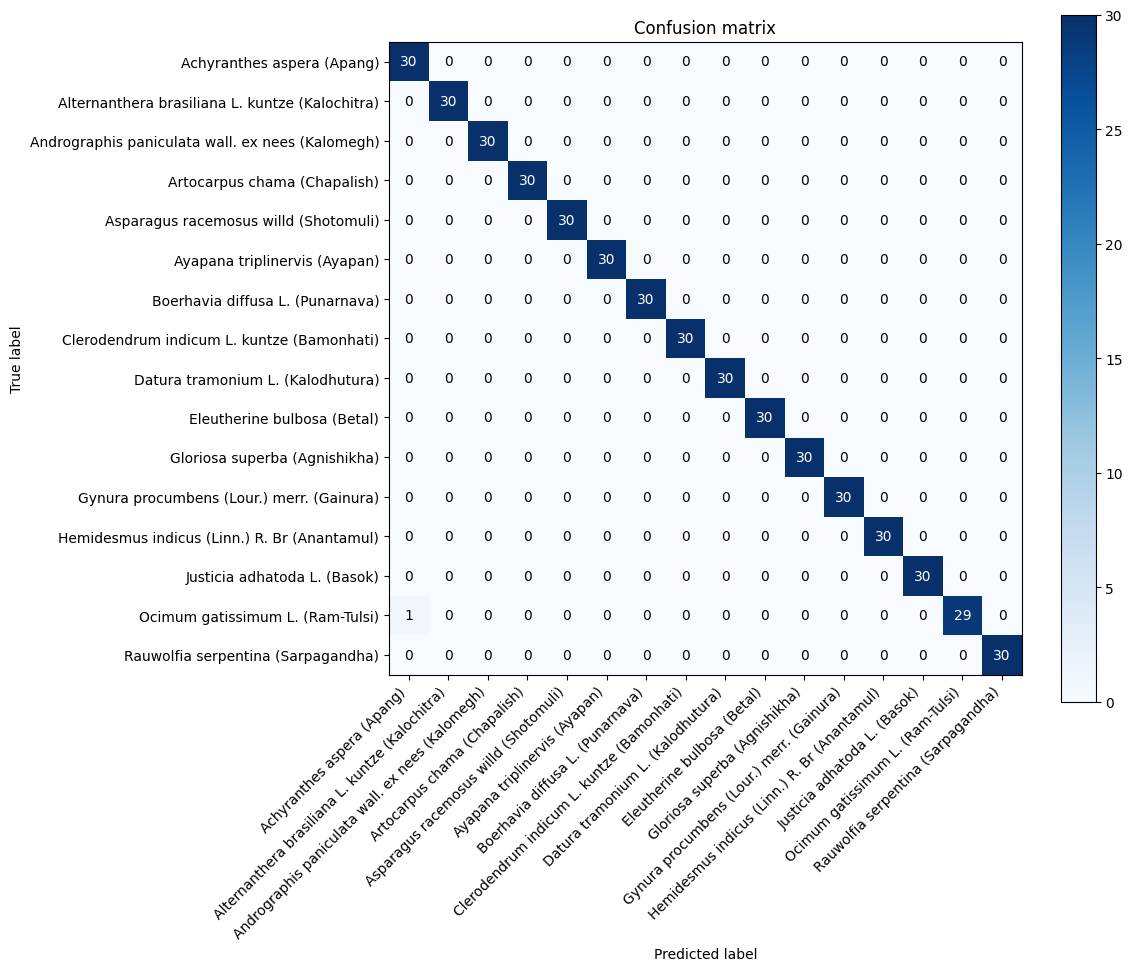

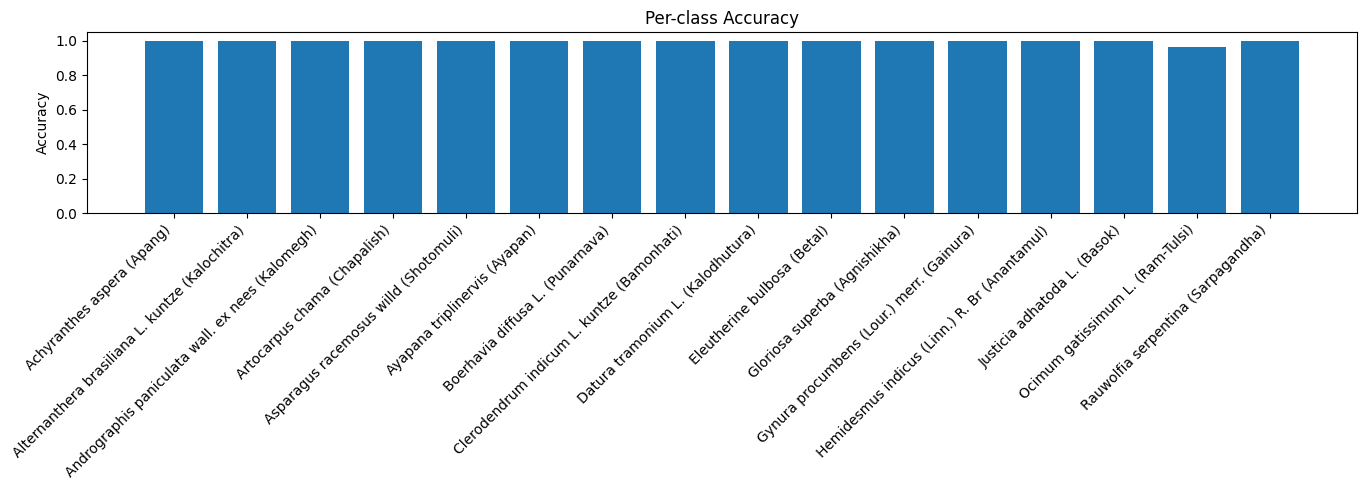

Saved metrics & confusion matrix to /content/drive/MyDrive/RareImage/GNN1_Results


In [8]:
# Cell 8 — Evaluate & save metrics (confusion matrix + csvs + per-class acc plot)
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report

# load best model
ckpt = torch.load(os.path.join(OUT_DIR, "best_model.pt"), map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device)

val = eval_one_epoch(model, test_loader, device, criterion)
if val is None:
    print("Test loader empty.")
else:
    test_loss, test_acc, preds, labels = val
    print(f"Test loss: {test_loss:.4f}  Test acc: {test_acc:.4f}")

    # metrics
    precision, recall, f1, support = precision_recall_fscore_support(labels, preds, average=None, labels=range(len(classes)))
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(labels, preds, average='micro')

    metrics = {
        'per_class': {},
        'macro': {'precision': float(macro_precision), 'recall': float(macro_recall), 'f1': float(macro_f1)},
        'micro': {'precision': float(micro_precision), 'recall': float(micro_recall), 'f1': float(micro_f1)},
        'accuracy': float(test_acc),
        'test_loss': float(test_loss)
    }
    # per-class accuracy
    per_class_correct = np.zeros(len(classes), dtype=int)
    per_class_total = np.zeros(len(classes), dtype=int)
    for t, p in zip(labels, preds):
        per_class_total[t] += 1
        if t == p:
            per_class_correct[t] += 1
    per_class_acc = per_class_correct / per_class_total

    for i, cls in enumerate(classes):
        metrics['per_class'][cls] = {
            'precision': float(precision[i]),
            'recall': float(recall[i]),
            'f1': float(f1[i]),
            'support': int(support[i]),
            'accuracy': float(per_class_acc[i])
        }

    # save json metrics
    with open(os.path.join(OUT_DIR, "test_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)

    # save per-class CSV
    df_metrics = pd.DataFrame({
        "class": classes,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
        "accuracy": per_class_acc
    })
    df_metrics.to_csv(os.path.join(OUT_DIR, "per_class_metrics.csv"), index=False)

    # global metrics CSV
    df_global = pd.DataFrame({
        "metric": ["macro_precision", "macro_recall", "macro_f1",
                   "micro_precision", "micro_recall", "micro_f1",
                   "overall_accuracy", "test_loss"],
        "value": [macro_precision, macro_recall, macro_f1,
                  micro_precision, micro_recall, micro_f1,
                  test_acc, test_loss]
    })
    df_global.to_csv(os.path.join(OUT_DIR, "global_metrics.csv"), index=False)

    # confusion matrix
    cm = confusion_matrix(labels, preds, labels=list(range(len(classes))))
    plt.figure(figsize=(12,10))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    # write counts
    for i in range(len(classes)):
        for j in range(len(classes)):
            plt.text(j, i, str(int(cm[i,j])), ha='center', va='center',
                     color="white" if cm[i,j] > cm.max()/2 else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=300)
    plt.show()

    # per-class accuracy bar
    plt.figure(figsize=(14,5))
    plt.bar(classes, per_class_acc)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Accuracy")
    plt.title("Per-class Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "per_class_accuracy.png"), dpi=300)
    plt.show()

    print("Saved metrics & confusion matrix to", OUT_DIR)
